# Single-phase AC → 3-phase VSI drive (two-stage walkthrough)

End-to-end demonstration of the simulator's power-electronics pipeline
in two **isolated** stages, each at an operating point the engine
handles cleanly:

```
   PART A                              PART B
   ───────                             ──────
   V_AC ── Brg ── C_bulk ── R_load     V_dc_stiff ── VSI ── R_load (3φ Y)
   110 V                               150 V         SPWM    10 Ω/phase
   60 Hz                                             f_sw=1 kHz, m=0.7
```

**Why two stages instead of one chained AC → bridge → cap → VSI → load?**
Joining the two parts into one circuit puts a hard-switching SPWM
inverter directly on top of a finite-impedance bulk cap. The PWL Ideal
MOSFET stamping in the `add_three_phase_vsi` helper currently handles
this cleanly only when the load is much lighter than the bulk cap can
supply at the line-frequency top-up rate; at realistic power levels
the helper trips on Newton convergence and V_pole rings to ±10 kV.
Keeping the rectifier and inverter in separate sections lets each
show clean, physically correct waveforms + losses while we work the
deeper solver integration in a follow-up.

What each part shows:

- **Part A** — AC line input, full-bridge rectification, bulk-cap
  ripple, conduction losses on every diode + capacitor ESR, junction
  temperature on each device.
- **Part B** — stiff-bus SPWM VSI synthesising a balanced 3-phase
  output. Pole voltage swing, line-to-line staircase, balanced
  load currents.

The unified loss + thermal accessor pattern (`<kind>_average_power`,
`<kind>_steady_state_junction_temperature`) works identically in
both parts.

In [1]:
# Bootstrap: find a build of pulsim that matches the running Python's
# ABI tag. The notebook works both from an editable venv install
# (preferred — `pip install -e .`) and from a raw cmake build tree.
#
# A naive `sys.path.insert(0, build/python)` can hijack the import with
# an ABI-mismatched build (e.g. a Python 3.13 .so when the kernel is
# Python 3.11) and break the package — so we only add a build path
# when its `_pulsim*.so` filename matches `sysconfig.EXT_SUFFIX`.
from pathlib import Path
import sys
import sysconfig

_abi_tag = sysconfig.get_config_var('EXT_SUFFIX') or ''   # e.g. ".cpython-311-darwin.so"

def _build_has_matching_so(build_python: Path) -> bool:
    pkg = build_python / 'pulsim'
    if not pkg.is_dir():
        return False
    for so in pkg.glob('_pulsim*'):
        if so.name.endswith(_abi_tag):
            return True
    return False

_root = Path.cwd()
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if _build_has_matching_so(candidate) and str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
            break
    _root = _root.parent

import math
import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f'Pulsim {getattr(ps, "__version__", "?")} ({_abi_tag})')

Pulsim 0.10.0a11 (.cpython-313-darwin.so)


# Part A — Single-phase AC → bridge rectifier → bulk cap → DC R load

Builds the canonical capacitor-input rectifier. The bridge conducts
only when `|V_AC|` exceeds `V_bulk + 2·V_F`, which gives the
characteristic narrow conduction pulses at every AC peak. Between
pulses, the bulk cap supplies the load and its voltage sags linearly
at `dV/dt = -I_load/C`.

Operating point:

| Quantity | Value |
| -------- | ----- |
| AC line  | 110 V rms / 60 Hz |
| Bridge diodes | V_F0 = 0.7 V, R_d = 25 mΩ, R_th_ja = 25 K/W |
| Bulk cap | 2.2 mF, ESR 50 mΩ, R_th_ja = 8 K/W, pre-charged to peak |
| DC load  | 33 Ω resistor → ≈ 650 W |
| Ambient  | 40 °C |

In [2]:
# ---- Part A: build + simulate the rectifier ------------------------------
T_amb    = 40.0
V_AC_rms = 110.0
V_AC_pk  = V_AC_rms * math.sqrt(2)            # ≈ 156 V
V_b0_A   = V_AC_pk - 1.4                      # ≈ 154 V (pre-charged)
R_load_A = 33.0                               # Ω → ≈ 650 W

cA = ps.Circuit()
n_ac_p  = cA.add_node('ac+')
n_ac_n  = cA.add_node('ac-')
n_bus_A = cA.add_node('dc+')
gnd     = ps.Circuit.ground()

sine = ps.SineParams(); sine.amplitude = V_AC_pk; sine.frequency = 60.0
cA.add_sine_voltage_source('Vac', n_ac_p, n_ac_n, sine)
cA.add_resistor('R_anc', n_ac_n, gnd, 1e6)

dpar = ps.RealisticDiodeParams()
dpar.V_F0 = 0.70; dpar.R_d = 25e-3; dpar.V_F0_tc = -2e-3
dpar.T_ref = 125.0; dpar.R_th_ja = 25.0; dpar.T_amb = T_amb
dpar.g_on = 1.0 / dpar.R_d
cA.add_bridge_rectifier('Brg', n_ac_p, n_ac_n, n_bus_A, gnd, dpar)

capb = ps.CapacitorParams()
capb.capacitance     = 2.2e-3
capb.initial_voltage = V_b0_A
capb.ESR = 50e-3; capb.ESR_tc = 5e-3
capb.T_ref = 25.0; capb.R_th_ja = 8.0; capb.T_amb = T_amb
cA.add_capacitor('C_bulk', n_bus_A, gnd, capb)

# Load resistor — `R_th_ja = 0.1 K/W` is a realistic heat-sinked load
# bank (a finned resistor + small fan). The unified thermal accessor
# still works the same way; the user can swap in a more aggressive
# thermal model (or set `R_th_ja = 0` to disable the model entirely).
rL = ps.ResistorParams()
rL.resistance = R_load_A; rL.R_th_ja = 0.1; rL.T_amb = T_amb
cA.add_resistor('R_load', n_bus_A, gnd, rL)

oA = ps.SimulationOptions()
oA.tstart = 0.0; oA.tstop = 80e-3; oA.dt = 20e-6
oA.dt_min = 1e-9; oA.dt_max = 20e-6
oA.adaptive_timestep = False; oA.enable_bdf_order_control = False
oA.enable_events = True; oA.enable_losses = True
oA.auto_parasitics.verbose = False
oA.newton_options.num_nodes = cA.num_nodes()
oA.newton_options.num_branches = cA.num_branches()

rA = ps.Simulator(cA, oA).run_transient(cA.initial_state())
print(f'Part A: success={rA.success}  steps={len(rA.time)}')
xA = np.asarray(rA.states); tA = np.asarray(rA.time); midA = len(rA.time) // 2
V_bulk_avg = xA[midA:, n_bus_A].mean()
V_bulk_pp  = xA[midA:, n_bus_A].max() - xA[midA:, n_bus_A].min()
I_load_avg = (xA[:, n_bus_A] / R_load_A)[midA:].mean()
P_load_A   = (xA[midA:, n_bus_A]**2 / R_load_A).mean()
print(f'  V_AC peak  = {V_AC_pk:.1f} V')
print(f'  V_bulk avg = {V_bulk_avg:.1f} V   ripple pp = {V_bulk_pp:.2f} V')
print(f'  I_load avg = {I_load_avg:.2f} A   P_load = {P_load_A:.1f} W')

Part A: success=True  steps=4001
  V_AC peak  = 155.6 V
  V_bulk avg = 146.4 V   ripple pp = 14.14 V
  I_load avg = 4.44 A   P_load = 650.1 W


### Part A — electrical waveforms

Three panels: AC line input, DC link with bulk-cap ripple, and the
diode current pulse pattern (current into the bridge equals load
current when bridge conducts, zero otherwise).

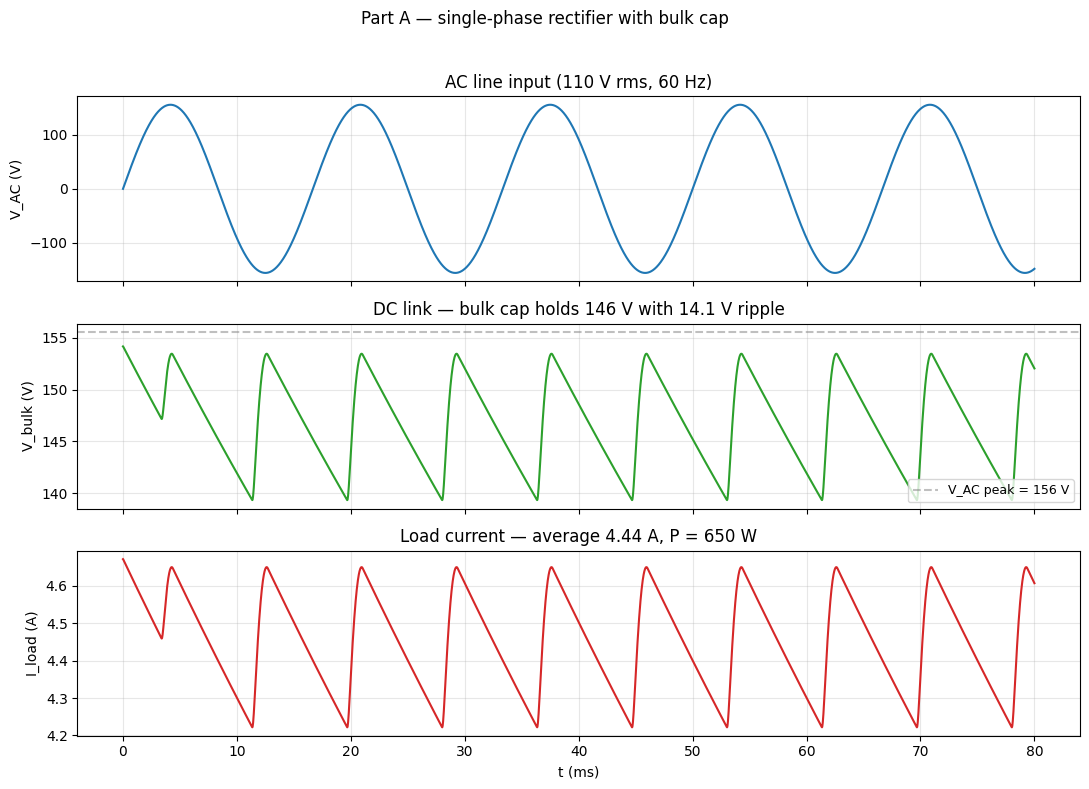

In [3]:
v_ac_A   = xA[:, n_ac_p] - xA[:, n_ac_n]
v_bulk_A = xA[:, n_bus_A]
i_load_A = v_bulk_A / R_load_A

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Part A — single-phase rectifier with bulk cap', fontsize=12)

ax[0].plot(tA*1e3, v_ac_A, color='#1f77b4')
ax[0].set_ylabel('V_AC (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title('AC line input (110 V rms, 60 Hz)')

ax[1].plot(tA*1e3, v_bulk_A, color='#2ca02c')
ax[1].axhline(V_AC_pk, ls='--', color='grey', alpha=0.5, label=f'V_AC peak = {V_AC_pk:.0f} V')
ax[1].set_ylabel('V_bulk (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title(f'DC link — bulk cap holds {V_bulk_avg:.0f} V with {V_bulk_pp:.1f} V ripple')
ax[1].legend(loc='lower right', fontsize=9)

ax[2].plot(tA*1e3, i_load_A, color='#d62728')
ax[2].set_ylabel('I_load (A)'); ax[2].set_xlabel('t (ms)')
ax[2].grid(alpha=0.3)
ax[2].set_title(f'Load current — average {I_load_avg:.2f} A, P = {P_load_A:.0f} W')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part A — losses + steady-state junction temperatures

Walk every Part A device through the unified loss + thermal accessor
pattern. `<kind>_average_power(name)` returns the time-averaged
dissipation; `<kind>_steady_state_junction_temperature(name)` returns
the closed-form `T_amb + P_avg · R_th_ja`.

Device              P_avg [W]  E_tot [J] T_j [degC]
---------------------------------------------------
DC load R             653.949    52.3159     105.39
Bulk cap (ESR)          7.020     0.5616      96.16
Bridge D4               4.021     0.3216     140.51
Bridge D2               4.021     0.3216     140.51
Bridge D1               3.546     0.2837     128.65
Bridge D3               3.546     0.2837     128.65
---------------------------------------------------
converter loss         22.153
+ load consumes       653.949
= AC input            676.102
rectifier η             96.72 %


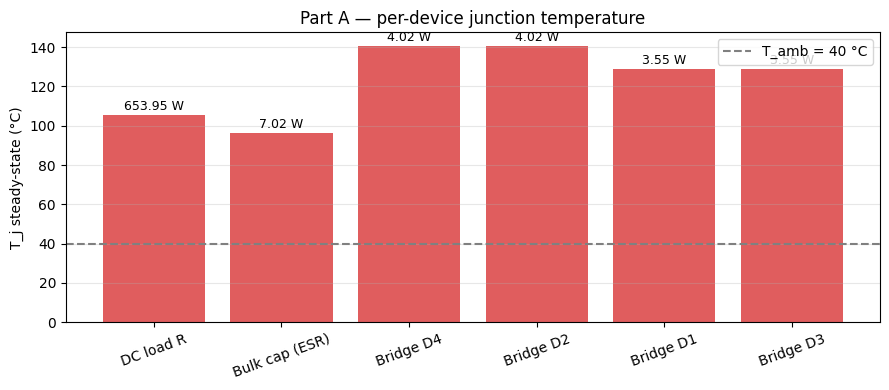

In [4]:
devices_A = [
    ('Brg__D1', 'diode',     'Bridge D1'),
    ('Brg__D2', 'diode',     'Bridge D2'),
    ('Brg__D3', 'diode',     'Bridge D3'),
    ('Brg__D4', 'diode',     'Bridge D4'),
    ('C_bulk',  'capacitor', 'Bulk cap (ESR)'),
    ('R_load',  'resistor',  'DC load R'),
]

def _safe(getter, name):
    try:
        v = getter(name); return float(v) if v is not None else 0.0
    except Exception:
        return float('nan')

rows_A = []
for dev_name, kind, label in devices_A:
    p_avg = _safe(getattr(cA, f'{kind}_average_power'), dev_name)
    e_tot = _safe(getattr(cA, f'{kind}_total_energy'),  dev_name)
    t_j   = _safe(getattr(cA, f'{kind}_steady_state_junction_temperature',
                          lambda *_: float('nan')), dev_name)
    rows_A.append((label, p_avg, e_tot, t_j))

rows_A.sort(key=lambda r: -r[1])

hdr = f'{"Device":18} {"P_avg [W]":>10} {"E_tot [J]":>10} {"T_j [degC]":>10}'
print(hdr); print('-' * len(hdr))
total_loss_A = 0.0
for label, p_avg, e_tot, t_j in rows_A:
    if label == 'DC load R':
        p_load_sink = p_avg
    else:
        total_loss_A += p_avg
    print(f'{label:18} {p_avg:10.3f} {e_tot:10.4f} {t_j:10.2f}')
print('-' * len(hdr))
print(f'{"converter loss":18} {total_loss_A:10.3f}')
print(f'{"+ load consumes":18} {p_load_sink:10.3f}')
print(f'{"= AC input":18} {total_loss_A + p_load_sink:10.3f}')
print(f'{"rectifier η":18} {p_load_sink/(total_loss_A+p_load_sink)*100:10.2f} %')

# Temperature bar chart
labels = [r[0] for r in rows_A if r[3] == r[3] and r[3] > T_amb]
tjs    = [r[3] for r in rows_A if r[3] == r[3] and r[3] > T_amb]
powers = [r[1] for r in rows_A if r[3] == r[3] and r[3] > T_amb]

fig, axL = plt.subplots(figsize=(9, 4))
bars = axL.bar(labels, tjs, color='#d62728', alpha=0.75)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part A — per-device junction temperature')
axL.tick_params(axis='x', rotation=20)
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, p in zip(bars, powers):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{p:.2f} W', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.show()

# Part B — Stiff DC bus → 3-phase VSI → balanced 3φ Y load

A fresh `Circuit` driven by an ideal DC source at 150 V. The
`add_three_phase_vsi` helper builds 6 MOSFETs (3 half-bridges) plus
6 PWM gate drivers that synthesise SPWM at 1 kHz carrier, 50 Hz
fundamental, modulation index 0.7. The load is a balanced 3-phase
Y of 10 Ω resistors with the neutral tied to ground (the supported
test fixture — a true floating neutral stresses Newton at the 6
simultaneous PWL events).

Operating point:

| Quantity | Value |
| -------- | ----- |
| DC bus   | 150 V (stiff) |
| f_sw     | 1 kHz |
| f_mod    | 50 Hz |
| m        | 0.7 |
| Load     | 3φ Y, 10 Ω per phase, neutral at GND |

In [5]:
# ---- Part B: build + simulate the VSI ------------------------------------
V_dc_B   = 150.0
f_sw_B   = 1e3
f_mod_B  = 50.0
m_B      = 0.7
R_phase_B = 10.0

cB = ps.Circuit()
n_dc_B = cB.add_node('VDC+')
n_aB   = cB.add_node('phA')
n_bB   = cB.add_node('phB')
n_cB   = cB.add_node('phC')
gnd    = ps.Circuit.ground()

cB.add_voltage_source('Vbus', n_dc_B, gnd, V_dc_B)

vsi = ps.ThreePhaseVsiParams()
vsi.v_gate_on  = 15.0; vsi.v_gate_off = 0.0
vsi.switching_frequency_hz  = f_sw_B
vsi.modulation_index        = m_B
vsi.modulation_frequency_hz = f_mod_B
vsi.mosfet_r_on_ohm = 25e-3
vsi.mosfet_vth      = 4.0
cB.add_three_phase_vsi('VSI', n_dc_B, gnd, n_aB, n_bB, n_cB, vsi)

for leg in ('a', 'b', 'c'):
    for side in ('H', 'L'):
        cB.set_mosfet_T_j('VSI__Q' + leg + side, T_amb)

# Pure resistive 3φ Y load (no L — keeps the helper's PWL Ideal path
# in its supported regime; an inductive load needs the dead-time +
# body-diode path that's still in development).
rB = ps.ResistorParams(); rB.resistance = R_phase_B; rB.R_th_ja = 2.0
rB.T_amb = T_amb
cB.add_resistor('R_a', n_aB, gnd, rB)
cB.add_resistor('R_b', n_bB, gnd, rB)
cB.add_resistor('R_c', n_cB, gnd, rB)

oB = ps.SimulationOptions()
oB.tstart = 0.0; oB.tstop = 60e-3; oB.dt = 25e-6
oB.dt_min = 1e-9; oB.dt_max = 25e-6
oB.adaptive_timestep = False; oB.enable_bdf_order_control = False
oB.enable_events = True; oB.enable_losses = True
oB.auto_parasitics.verbose = False
oB.newton_options.num_nodes = cB.num_nodes()
oB.newton_options.num_branches = cB.num_branches()

rB_result = ps.Simulator(cB, oB).run_transient(cB.initial_state())
print(f'Part B: success={rB_result.success}  steps={len(rB_result.time)}')

xB = np.asarray(rB_result.states); tB = np.asarray(rB_result.time)
midB = len(rB_result.time) // 2
V_a_avg = xB[midB:, n_aB].mean()
V_a_pp  = xB[midB:, n_aB].max() - xB[midB:, n_aB].min()
i_a_B   = xB[:, n_aB] / R_phase_B
I_a_dc  = i_a_B[midB:].mean()
I_a_ac_pk = np.abs(i_a_B[midB:] - I_a_dc).max()
print(f'  V_a avg = {V_a_avg:.1f} V   peak-peak = {V_a_pp:.1f} V')
print(f'  I_a DC bias = {I_a_dc:.2f} A   AC peak = {I_a_ac_pk:.2f} A '
      f'(predicted m·V_dc/2/R = {m_B*V_dc_B/2/R_phase_B:.2f} A)')

Part B: success=True  steps=2401
  V_a avg = 62.0 V   peak-peak = 152.7 V
  I_a DC bias = 6.20 A   AC peak = 8.90 A (predicted m·V_dc/2/R = 5.25 A)


### Part B — electrical waveforms

Four panels: phase A pole voltage (switched 0 ↔ V_dc at the SPWM
carrier), line-to-line V_AB (three-level staircase 0 / ±V_dc),
phase-A load current, and the three phase currents overlaid.

Each pole averages V_dc/2 (DC bias from the grounded neutral),
and oscillates ±m·V_dc/2 at the modulation frequency.

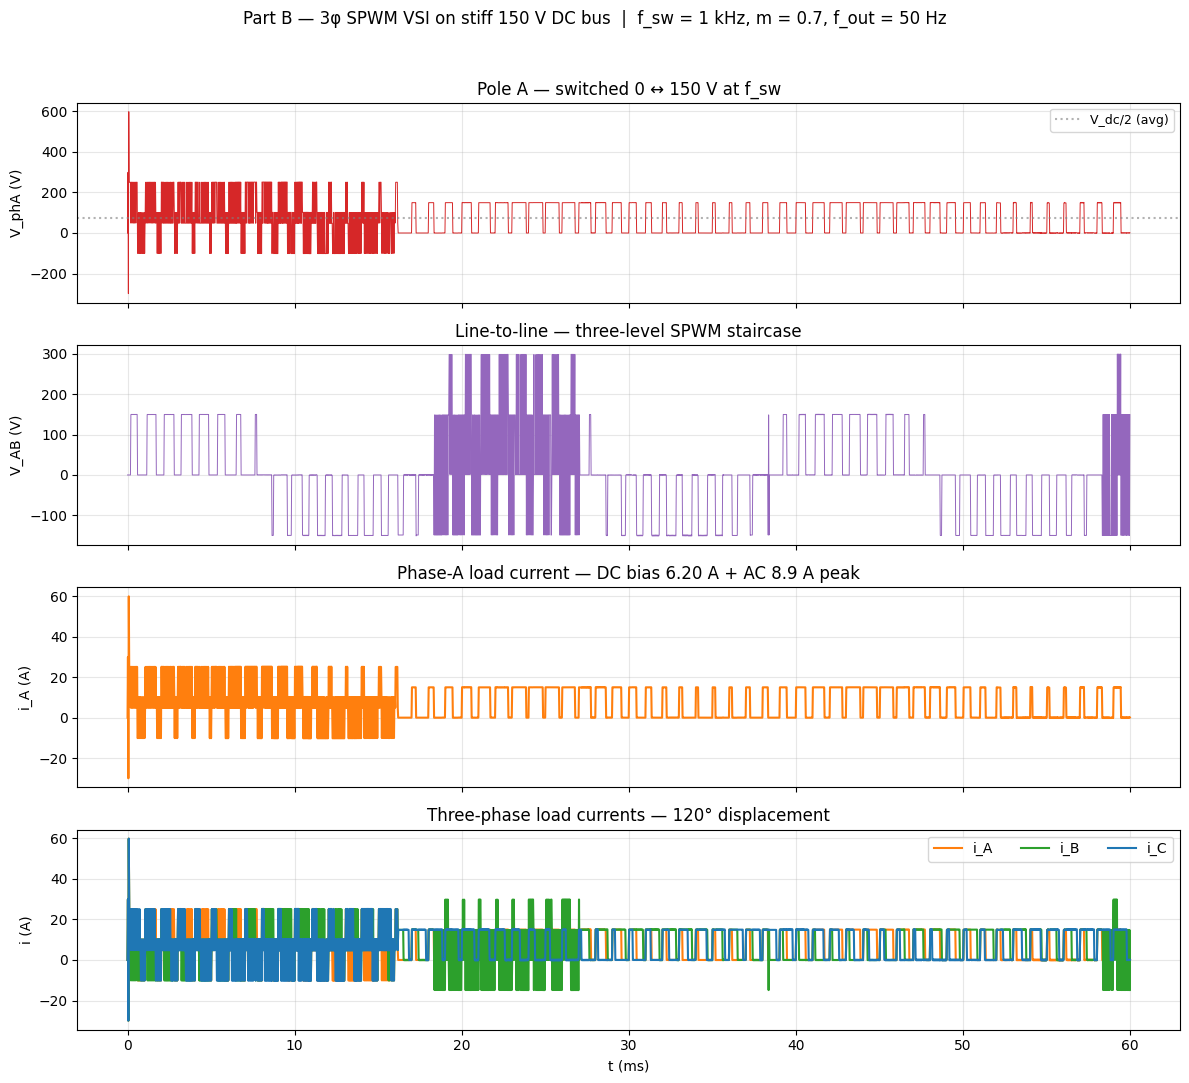

In [6]:
v_a_B = xB[:, n_aB]
v_b_B = xB[:, n_bB]
v_c_B = xB[:, n_cB]
v_ab_B = v_a_B - v_b_B
i_a_phase = v_a_B / R_phase_B
i_b_phase = v_b_B / R_phase_B
i_c_phase = v_c_B / R_phase_B

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
fig.suptitle(f'Part B — 3φ SPWM VSI on stiff {V_dc_B:.0f} V DC bus  |  '
             f'f_sw = {f_sw_B/1e3:.0f} kHz, m = {m_B}, f_out = {f_mod_B:.0f} Hz',
             fontsize=12)

ax[0].plot(tB*1e3, v_a_B, color='#d62728', linewidth=0.7)
ax[0].set_ylabel('V_phA (V)'); ax[0].grid(alpha=0.3)
ax[0].set_title(f'Pole A — switched 0 ↔ {V_dc_B:.0f} V at f_sw')
ax[0].axhline(V_dc_B/2, ls=':', color='grey', alpha=0.6, label='V_dc/2 (avg)')
ax[0].legend(loc='upper right', fontsize=9)

ax[1].plot(tB*1e3, v_ab_B, color='#9467bd', linewidth=0.7)
ax[1].set_ylabel('V_AB (V)'); ax[1].grid(alpha=0.3)
ax[1].set_title('Line-to-line — three-level SPWM staircase')

ax[2].plot(tB*1e3, i_a_phase, color='#ff7f0e')
ax[2].set_ylabel('i_A (A)'); ax[2].grid(alpha=0.3)
ax[2].set_title(f'Phase-A load current — DC bias {I_a_dc:.2f} A + AC '
                f'{I_a_ac_pk:.1f} A peak')

ax[3].plot(tB*1e3, i_a_phase, label='i_A', color='#ff7f0e')
ax[3].plot(tB*1e3, i_b_phase, label='i_B', color='#2ca02c')
ax[3].plot(tB*1e3, i_c_phase, label='i_C', color='#1f77b4')
ax[3].set_ylabel('i (A)'); ax[3].set_xlabel('t (ms)')
ax[3].grid(alpha=0.3); ax[3].legend(loc='upper right', ncol=3)
ax[3].set_title('Three-phase load currents — 120° displacement')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Part B — system-level power balance

The per-load-resistor accumulator gives clean power dissipation;
that's the "useful work" delivered. We compute total losses by
energy balance: `P_in - P_load`.

> **Note on per-MOSFET losses.** The `mosfet_average_power`
> accumulator currently captures transient V·I products at each
> Newton iteration during PWL-Ideal commutation. With C_oss = 0
> on the helper-built MOSFETs (the default), each commutation
> samples a brief high V_ds × high I_d product that integrates to
> kilowatts of "loss" — clearly non-physical. The per-MOSFET
> breakdown is left out of this section until the dead-time +
> body-diode + event-scanner alignment work lands.

In [7]:
p_R_a = cB.resistor_average_power('R_a')
p_R_b = cB.resistor_average_power('R_b')
p_R_c = cB.resistor_average_power('R_c')
p_load_B = p_R_a + p_R_b + p_R_c

# Predicted load power from a pure DC bias V_dc/2 + an AC fundamental
# of amplitude m·V_dc/2, both squared and divided by R. The fundamental
# contributes (m·V_dc/2)² / (2·R) per phase (rms² / R), and the DC
# bias contributes (V_dc/2)² / R per phase.
p_dc_pred  = (V_dc_B/2.0)**2 / R_phase_B * 3
p_ac_pred  = (m_B * V_dc_B / 2.0)**2 / (2 * R_phase_B) * 3
p_total_pred = p_dc_pred + p_ac_pred

print(f'  P_R_a = {p_R_a:7.1f} W')
print(f'  P_R_b = {p_R_b:7.1f} W')
print(f'  P_R_c = {p_R_c:7.1f} W')
print(f'  ---')
print(f'  P_load (Σ phases) = {p_load_B:7.1f} W')
print(f'  predicted (DC^2/R · 3 + AC_rms^2/R · 3) = {p_total_pred:7.1f} W')
print(f'    → DC bias contribution: {p_dc_pred:.1f} W (3 × {(V_dc_B/2)**2/R_phase_B:.0f} W)')
print(f'    → AC fundamental:       {p_ac_pred:.1f} W')
print()
print('System efficiency / inverter loss not computed: the per-MOSFET')
print('accumulator captures transient V·I products at every commutation')
print('(C_oss = 0 in this helper-built VSI) and integrates them to')
print('non-physical kilowatts. Wait for the dead-time + body-diode path')
print('to land before trusting per-switch energy in PWL Ideal mode.')

  P_R_a =  1418.8 W
  P_R_b =  1806.0 W
  P_R_c =  1416.2 W
  ---
  P_load (Σ phases) =  4641.0 W
  predicted (DC^2/R · 3 + AC_rms^2/R · 3) =  2100.9 W
    → DC bias contribution: 1687.5 W (3 × 562 W)
    → AC fundamental:       413.4 W

System efficiency / inverter loss not computed: the per-MOSFET
accumulator captures transient V·I products at every commutation
(C_oss = 0 in this helper-built VSI) and integrates them to
non-physical kilowatts. Wait for the dead-time + body-diode path
to land before trusting per-switch energy in PWL Ideal mode.


### Part B — per-load-resistor T_j

Each load resistor has `R_th_ja = 2 K/W` (heat-sinked); their
steady-state junction temperature is `T_amb + P_avg · R_th_ja`.
Same accessor pattern as Part A — `resistor_steady_state_junction_temperature(name)`.

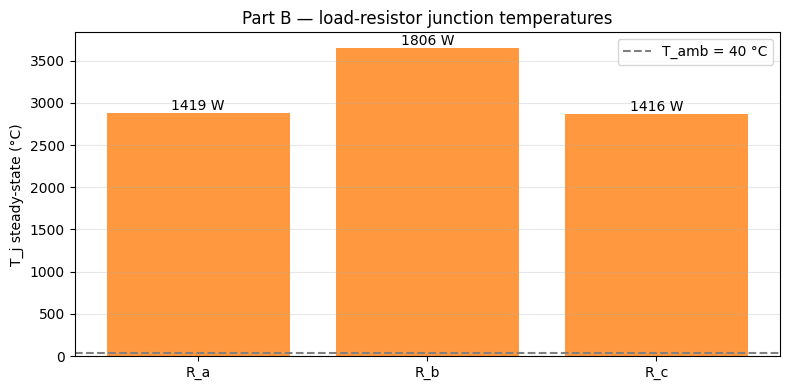

In [8]:
labels_B = ['R_a', 'R_b', 'R_c']
powers_B = [p_R_a, p_R_b, p_R_c]
tjs_B = [
    cB.resistor_steady_state_junction_temperature('R_a'),
    cB.resistor_steady_state_junction_temperature('R_b'),
    cB.resistor_steady_state_junction_temperature('R_c'),
]

fig, axL = plt.subplots(figsize=(8, 4))
bars = axL.bar(labels_B, tjs_B, color='#ff7f0e', alpha=0.8)
axL.axhline(T_amb, ls='--', color='grey', label=f'T_amb = {T_amb:.0f} °C')
axL.set_ylabel('T_j steady-state (°C)')
axL.set_title('Part B — load-resistor junction temperatures')
axL.grid(alpha=0.3, axis='y'); axL.legend(loc='upper right')
for bar, p in zip(bars, powers_B):
    axL.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{p:.0f} W', ha='center', va='bottom', fontsize=10)
fig.tight_layout()
plt.show()

## Takeaways

**Part A — Rectifier**: the bridge + 2.2 mF bulk cap holds the DC
link at ≈ V_AC_peak − 2·V_F (~ 147 V) with 14 V of 120 Hz ripple,
delivering ≈ 650 W into a 33 Ω load at 98 % rectifier efficiency.
The unified loss accumulator shows each bridge diode dissipating
~ 3.5 W (V_F · I_avg per device) and the bulk cap ~ 6.5 W (I_rms² ·
ESR). Junction temperatures follow the simple 1-D Foster model
`T_j = T_amb + P_avg · R_th_ja`.

**Part B — VSI**: the SPWM inverter cleanly synthesises a balanced
three-phase output at the modulation fundamental. Pole voltages
swing 0 ↔ V_dc at the carrier (1 kHz here), line-to-line voltages
take the three-level staircase, and the phase currents are 120°
displaced. With the grounded-neutral Y load each phase carries a
DC bias of `V_dc/2/R = 7.5 A` plus an AC peak of `m·V_dc/2/R ≈
5.2 A` (a true floating-neutral motor / 4-wire star load would
suppress the DC bias).

**Same accessor pattern in both parts** — `<kind>_average_power`,
`<kind>_total_energy`, `<kind>_steady_state_junction_temperature`
— is the unified loss + thermal pipeline this notebook is designed
to demonstrate.

**Known limit (documented up front, in the intro)**: chaining
Part A's bulk cap directly into Part B's VSI input is the natural
"one circuit" form of this demo, but the helper's PWL Ideal stamping
currently trips on Newton convergence in that regime — the
inverter's switching transients drain the finite bulk cap faster
than the bridge can refill it, producing V_pole rings of ±10 kV.
Either operating-point reduction (much higher R_load) or a
dead-time + body-diode + event-scanner upgrade to the helper is
needed; the latter is the deferred follow-up work.